In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 


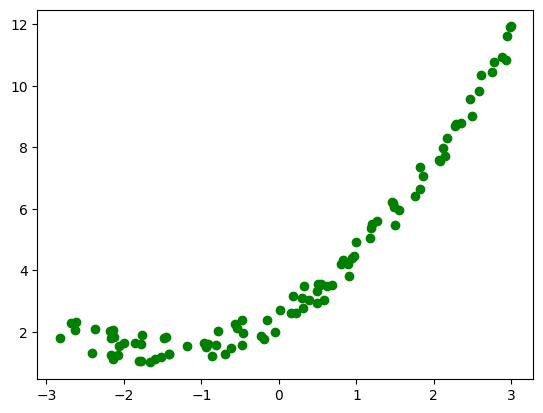

In [11]:
X = 6 * np.random.rand(100,1)-3
y = 0.5*X**2+1.5*X+2+np.random.rand(100,1)
plt.scatter(X,y,color = 'g')


In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [13]:
## simple linear reg
from sklearn.linear_model import LinearRegression
regresser = LinearRegression()
regresser.fit(X_train,y_train)

LinearRegression()

In [20]:
from sklearn.metrics import r2_score
score = r2_score(y_test,regresser.predict(X_test) )
print(score)

0.7691389377467651


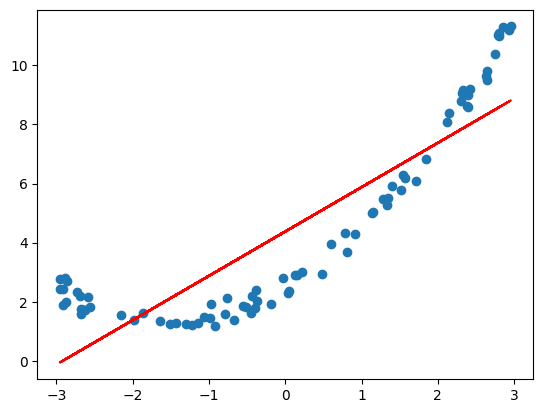

In [23]:
plt.plot(X_train,regresser.predict(X_train),color = 'r')
plt.scatter(X_train,y_train)

### now we will use poly regression 


In [8]:
from sklearn.preprocessing import PolynomialFeatures

In [26]:
poly = PolynomialFeatures(degree = 2 , include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_teST_poly = poly.transform(X_test)

In [27]:
X_train_poly

array([[ 1.00000000e+00, -6.71873014e-01,  4.51413348e-01],
       [ 1.00000000e+00, -5.52486272e-01,  3.05241080e-01],
       [ 1.00000000e+00,  1.51320504e+00,  2.28978950e+00],
       [ 1.00000000e+00,  1.71289650e+00,  2.93401441e+00],
       [ 1.00000000e+00, -1.14624001e+00,  1.31386615e+00],
       [ 1.00000000e+00,  1.84741561e+00,  3.41294444e+00],
       [ 1.00000000e+00, -2.69342142e+00,  7.25451894e+00],
       [ 1.00000000e+00, -1.86191574e+00,  3.46673024e+00],
       [ 1.00000000e+00,  2.79839247e+00,  7.83100043e+00],
       [ 1.00000000e+00,  5.93754733e-01,  3.52544683e-01],
       [ 1.00000000e+00, -2.63841895e+00,  6.96125457e+00],
       [ 1.00000000e+00,  4.23984430e-02,  1.79762797e-03],
       [ 1.00000000e+00,  1.33673875e-01,  1.78687050e-02],
       [ 1.00000000e+00,  2.39393049e+00,  5.73090320e+00],
       [ 1.00000000e+00, -1.98593548e+00,  3.94393974e+00],
       [ 1.00000000e+00,  2.64419399e+00,  6.99176187e+00],
       [ 1.00000000e+00,  2.32515857e+00

In [31]:
regresser = LinearRegression()
regresser.fit(X_train_poly,y_train)
y_pred = regresser.predict(X_teST_poly)
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.9918253224245717


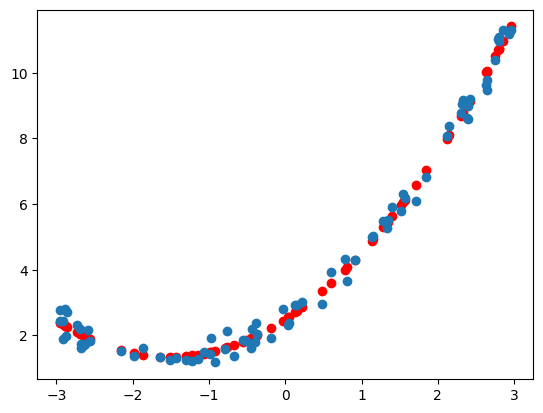

In [39]:
plt.scatter(X_train,regresser.predict(X_train_poly),color = 'r')
plt.scatter(X_train,y_train)

In [ ]:
## let us check for deg 3 

In [14]:
poly = PolynomialFeatures(degree = 3 , include_bias = True)
X_train_poly = poly.fit_transform(X_train)
X_teST_poly = poly.transform(X_test)

In [41]:
regresser = LinearRegression()
regresser.fit(X_train_poly,y_train)
y_pred = regresser.predict(X_teST_poly)
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.992104777221044


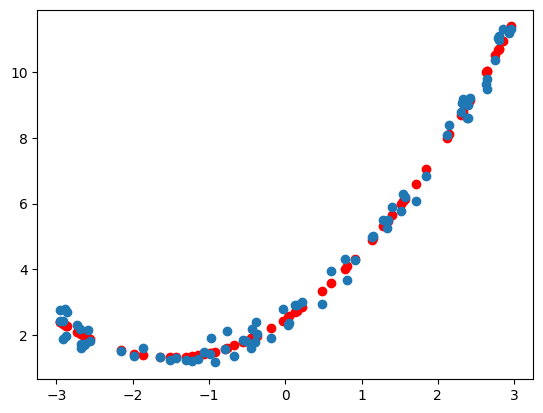

In [43]:
plt.scatter(X_train,regresser.predict(X_train_poly),color = 'r')
plt.scatter(X_train,y_train)

In [46]:
## prediction of new data 
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

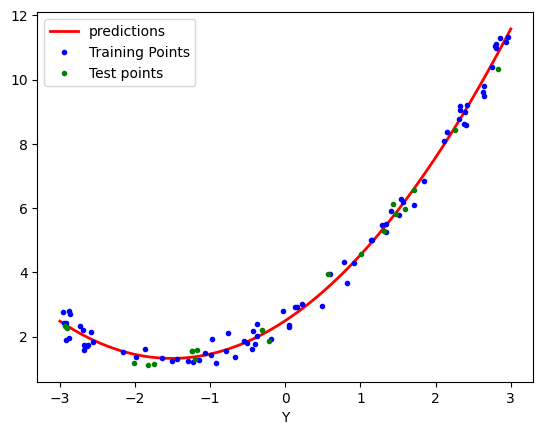

In [ ]:
y_new = regresser.predict(X_new_poly)
plt.plot(X_new,y_new,"r-",linewidth= 2, label = " New predictions")
plt.plot(X_train,y_train,"b.",label = "Training Points")
plt.plot(X_test,y_test,"g.",linewidth= 2, label = "Test points")
plt.xlabel("X")
plt.xlabel("Y")
plt.legend()
plt.show()

## PIPE-LINE

In [2]:
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)
    poly_features = PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg = LinearRegression()
    poly_pipe = Pipeline([
        ("poly_feature",poly_features),
         ("lin_reg",lin_reg)
                    ])
    poly_pipe.fit(X_train,y_train)
    y_pred_nw = poly_pipe.predict(X_new)
 ## plooting predcition line
    plt.plot(X_new,y_pred_nw,'r',label = "degree"+ str(degree),linewidth = 2)
    plt.plot(X_train,y_train,'b.',linewidth = 2)
    plt.plot(X_test,y_test,'g.',linewidth = 2)
    plt.legend(loc = "upper left")
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.show()



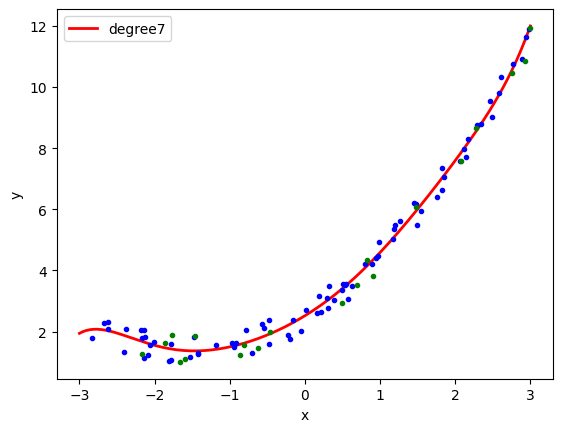

In [27]:
poly_regression(7)